# Kaggriculture Daily Replays: The Live Meta Report

*By [Georgy Mamarin](https://www.kaggle.com/georgymamarin)*

Every finished game on the [Kaggriculture](https://www.kaggle.com/competitions/kaggriculture)
ladder leaves a full public replay: 720 turns, both players, every observation and every action.
I collect them into the
[Kaggriculture Episodes](https://www.kaggle.com/datasets/georgymamarin/kaggriculture-episodes)
dataset, and this notebook is the live look inside: what the data holds today, and what the
leading farms measurably do differently.

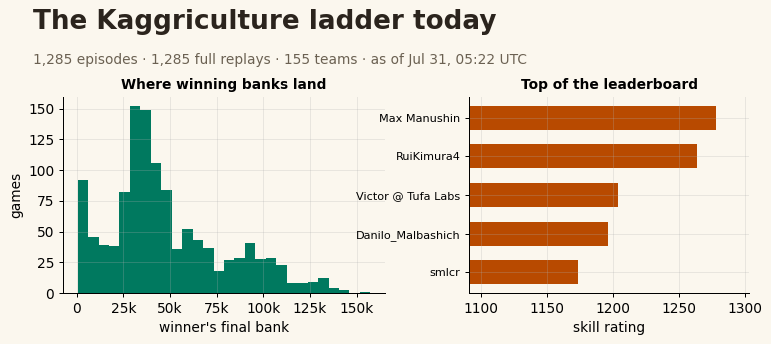

pandas 2.3.3 · numpy 2.0.2 · executed 2026-07-31 09:42 UTC · full run ~1 min


In [1]:
# Reads the dataset in place: on Kaggle from /kaggle/input, locally from the staging copy.
import glob, json, os, textwrap
from datetime import timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

hits = (glob.glob("/kaggle/input/**/episodes.csv", recursive=True)
        + glob.glob("../episodes_dataset/episodes.csv")
        + glob.glob("../../episodes_dataset/episodes.csv"))
if not hits:
    raise FileNotFoundError("episodes.csv not found — attach the kaggriculture-episodes dataset")
BASE = os.path.dirname(hits[0])

eps = pd.read_csv(f"{BASE}/episodes.csv")
agents = pd.read_csv(f"{BASE}/agents.csv")
try:                                                      # ids are unreadable on charts
    teams = pd.read_csv(f"{BASE}/teams.csv")
except FileNotFoundError:                                 # older dataset version
    teams = pd.DataFrame(columns=["team_id", "team_name", "ladder_score", "last_submission"])
NAME = dict(zip(teams.team_id, teams.team_name))
name_of = lambda tid: NAME.get(tid, f"team {tid}")
replay_ids = set(pd.read_parquet(f"{BASE}/replays.parquet", columns=["episode_id"]).episode_id)

def load_replay(episode_id):
    # One replay by id; parquet filters keep memory tiny.
    df = pd.read_parquet(f"{BASE}/replays.parquet",
                         filters=[("episode_id", "==", int(episode_id))])
    return json.loads(df.replay_json.iloc[0])

eps["has_replay"] = eps.episode_id.isin(replay_ids)
eps["winner_bank"] = eps[["bank_0", "bank_1"]].max(axis=1)
eps["end"] = pd.to_datetime(eps.end_time, format="mixed", utc=True)
ladder = eps[eps.type.eq("EPISODE_TYPE_PUBLIC") & eps.state.eq("COMPLETED")
             & eps.winner_bank.gt(0)].copy()
ladder_r = ladder[ladder.has_replay]
AS_OF = eps.end.max()

plt.rcParams.update({
    "figure.dpi": 90, "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25,
})
C_TOP, C_MID, C_LOW, C_ACC = "#00795F", "#B84A00", "#9E2B72", "#0072B2"
fmt = lambda v: f"{v:,.0f}"

# ---- poster: the ladder at a glance, first thing on the page ----
lb = teams.dropna(subset=["ladder_score"]).sort_values("ladder_score", ascending=False)
if lb.empty:      # no names yet: fall back to the ratings recorded in the episodes
    last = agents.sort_values("episode_id").groupby("team_id").rating_after.last()
    lb = (last.reset_index().rename(columns={"rating_after": "ladder_score"})
          .assign(team_name=lambda d: d.team_id.map(lambda t: f"team {t}"))
          .sort_values("ladder_score", ascending=False))
top5 = lb.head(5).iloc[::-1]
ladder0 = eps[eps.type.eq("EPISODE_TYPE_PUBLIC") & eps.state.eq("COMPLETED")]
banks = ladder0[["bank_0", "bank_1"]].max(axis=1).dropna()

fig = plt.figure(figsize=(8.2, 3.9))
fig.patch.set_facecolor("#FBF7EE")
fig.text(.015, .97, "The Kaggriculture ladder today", fontsize=21, weight="bold",
         color="#2B241D", va="top")
fig.text(.015, .845,
         f"{len(eps):,} episodes · {len(replay_ids):,} full replays · {len(lb):,} teams · "
         f"as of {AS_OF:%b %d, %H:%M UTC}", fontsize=11, color="#6B6152", va="top")
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1], top=.72, bottom=.16, left=.055, right=.985,
                      wspace=.28)
ax1 = fig.add_subplot(gs[0]); ax1.set_facecolor("#FBF7EE")
ax1.hist(banks, bins=28, color="#00795F")
ax1.set_title("Where winning banks land", fontsize=11)
ax1.set_xlabel("winner's final bank"); ax1.set_ylabel("games")
ax1.xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k" if v else "0")
ax2 = fig.add_subplot(gs[1]); ax2.set_facecolor("#FBF7EE")
ax2.barh(range(len(top5)), top5.ladder_score, color="#B84A00", height=.62)
ax2.set_yticks(range(len(top5)),
               [n if len(n) < 19 else n[:17] + "…" for n in top5.team_name], fontsize=9)
ax2.set_title("Top of the leaderboard", fontsize=11)
if top5.ladder_score.nunique() > 1:
    ax2.set_xlim(min(top5.ladder_score) * .93, max(top5.ladder_score) * 1.02)
ax2.set_xlabel("skill rating")
plt.show()
print(f"pandas {pd.__version__} · numpy {np.__version__} · "
      f"executed {pd.Timestamp.now(tz='UTC'):%Y-%m-%d %H:%M} UTC · full run ~1 min")

**A live report, not a snapshot.** It re-runs on a schedule with the dataset, so every number in
the text below is computed at run time. Come back tomorrow and the ladder you see will be the
ladder as it is tomorrow.

Two companions, two jobs: this one is about the data and the state of the ladder; my guide
[Kaggriculture, Visualized](https://www.kaggle.com/code/georgymamarin/kaggriculture-visualized-what-every-crop-pays)
is about the game itself, with every rule and price curve drawn out plus a starter bot. Read that
one first if the mechanics are new to you.

### In this notebook

1. [What is in the dataset today](#s1) — size, coverage, and how fast the corpus grows
2. [The ladder right now](#s2) — every recorded win on one chart
3. [The shape of a big game](#s3) — top coin curves against a median game
4. [Strategy fingerprints](#s4) — crew, land and crops: leaders vs the mid-ladder
5. [The market they create together](#s5) — prices inside the record game
6. [How fast the bar is moving](#s6) — the meta clock, in percent per day
7. [Who beats whom](#s7) — head-to-head win rates the ratings hide
8. [How much of this is luck](#s8) — same bot, different games
9. [Your submission against the ladder](#s9) — a personal report; edit one line

Plus [the honest caveats](#s10) behind every chart, and the [takeaways](#s11).

<a id="s1"></a>
## 1. What is in the dataset today

Before the strategy talk, the shape of the data itself: how much of the ladder is captured, how
deep the replay coverage goes, and how fast the corpus grows. Column-level docs live on the
[dataset page](https://www.kaggle.com/datasets/georgymamarin/kaggriculture-episodes).

metric,value
episodes,"1,285"
with full replay,"1,285 (100%)"
ladder games,"1,196"
validation (self-play),89 (7%)
submissions seen,255
teams seen,95
ladder time covered,12 hours


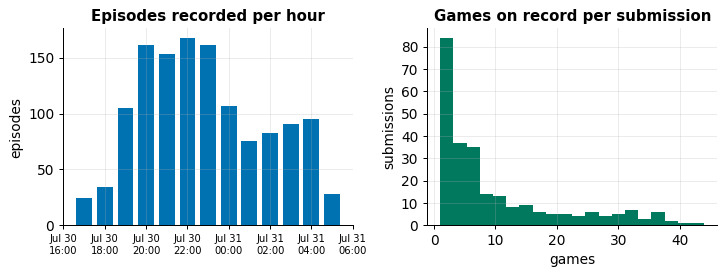

Coverage is **100%** of episodes; the busiest submission has **44** games on record and the median has **6**. Validation runs (7% of rows) are a submission playing itself. Filter them out before comparing strength; the rest of this notebook does.

In [2]:
n_subs = pd.unique(agents.submission_id).size
n_teams = pd.unique(agents.team_id).size
val_share = eps.type.eq("EPISODE_TYPE_VALIDATION").mean()
cover = eps.has_replay.mean()
span_h = (eps.end.max() - eps.end.min()).total_seconds() / 3600

summary = pd.DataFrame({
    "metric": ["episodes", "with full replay", "ladder games", "validation (self-play)",
               "submissions seen", "teams seen", "ladder time covered"],
    "value": [f"{len(eps):,}", f"{len(replay_ids):,} ({cover:.0%})", f"{len(ladder):,}",
              f"{eps.type.eq('EPISODE_TYPE_VALIDATION').sum():,} ({val_share:.0%})",
              f"{n_subs:,}", f"{n_teams:,}",
              f"{span_h:.0f} hours" if span_h <= 72 else f"{span_h / 24:.1f} days"],
})
display(summary.style.hide(axis="index").set_properties(**{"font-size": "13px"})
        .set_table_styles([{"selector": "th", "props": [("font-size", "13px")]}]))

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.2))
freq1, width1, unit1 = ("1h", 0.032, "hour") if span_h <= 72 else ("1D", 0.8, "day")
by_t = eps.set_index("end").resample(freq1).size()
axes[0].bar(by_t.index, by_t.values, width=width1, color=C_ACC)
axes[0].set_title(f"Episodes recorded per {unit1}"); axes[0].set_ylabel("episodes")
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %d\n%H:%M"))
axes[0].tick_params(axis="x", labelsize=8)
games = agents.groupby("submission_id").size().sort_values(ascending=False)
axes[1].hist(games.values, bins=min(20, games.nunique()), color=C_TOP)
axes[1].set_title("Games on record per submission")
axes[1].set_xlabel("games"); axes[1].set_ylabel("submissions")
axes[1].yaxis.set_major_locator(plt.matplotlib.ticker.MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

display(Markdown(
    f"Coverage is **{cover:.0%}** of episodes; the busiest submission has **{games.max()}** games "
    f"on record and the median has **{games.median():.0f}**. Validation runs "
    f"({val_share:.0%} of rows) are a submission playing itself. Filter them out before comparing "
    f"strength; the rest of this notebook does."))

<a id="s2"></a>
## 2. The ladder right now

Winners' final banks across the recorded ladder games, one dot per episode. The spread is the
story of this competition: the same board and the same rules produce farms that differ by an
order of magnitude.

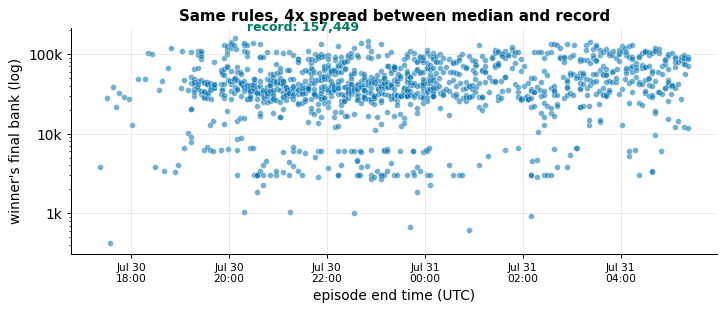

The winner's bank across recorded games: **28,707** at p25, **39,652** median, **96,424** at p90. The record of **157,449** is **4.0×** the median win; section 6 tracks how fast that gap moves.

In [3]:
fig, ax = plt.subplots(figsize=(8.2, 3.6))
ax.scatter(ladder.end, ladder.winner_bank, s=22, alpha=.55, color=C_ACC, edgecolors="white", lw=.4)
rec = ladder.loc[ladder.winner_bank.idxmax()]
ax.annotate(f"record: {fmt(rec.winner_bank)}", xy=(rec.end, rec.winner_bank),
            xytext=(10, 6), textcoords="offset points", fontsize=10, weight="bold", color=C_TOP)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:g}k" if v >= 1000 else f"{v:g}")
ax.set_ylabel("winner's final bank (log)"); ax.set_xlabel("episode end time (UTC)")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %d\n%H:%M"))
ax.tick_params(axis="x", labelsize=8.5)
ax.set_title(f"Same rules, {ladder.winner_bank.max() / ladder.winner_bank.median():.0f}x spread "
             "between median and record")
plt.tight_layout(); plt.show()

q = ladder.winner_bank.quantile([.25, .5, .9])
display(Markdown(
    f"The winner's bank across recorded games: **{fmt(q[.25])}** at p25, **{fmt(q[.5])}** median, "
    f"**{fmt(q[.9])}** at p90. The record of **{fmt(rec.winner_bank)}** is "
    f"**{rec.winner_bank / q[.5]:.1f}×** the median win; section 6 tracks how fast that gap moves."))

<a id="s3"></a>
## 3. The shape of a big game

Coin curves of the biggest wins on record against a median game. Top games share a silhouette:
the bank stays near zero deep into the season while everything is reinvested, then compounding
takes over once the farm is built.

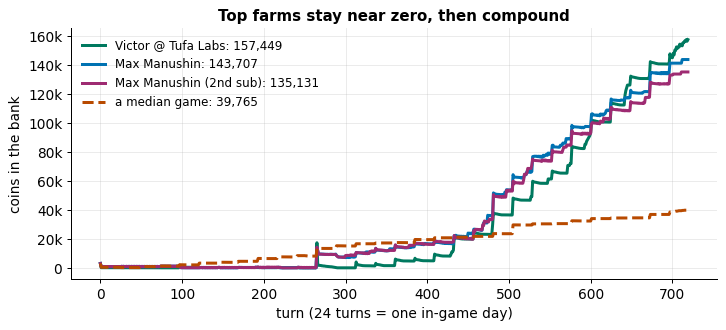

Each top farm crosses a tenth of its final bank on in-game day **11** (top-1), **15** (top-2), **11** (top-3). That crossing, not the last-day sprint, is where the game is decided.

In [4]:
ladder_r = ladder_r.assign(
    winner_sub=np.where(ladder_r.bank_0 >= ladder_r.bank_1, ladder_r.sub_0, ladder_r.sub_1))
top_subs = ladder_r.groupby("winner_sub").winner_bank.max().nlargest(3)

def money_curve(row, seat):
    return [s[0]["observation"]["farms"][seat]["money"]
            for s in load_replay(row.episode_id)["steps"]]

fig, ax = plt.subplots(figsize=(8.2, 3.8))
elbows, seen_teams = {}, set()
for rank, (sub, bank) in enumerate(top_subs.items()):
    row = ladder_r[ladder_r.winner_sub.eq(sub) & ladder_r.winner_bank.eq(bank)].iloc[0]
    seat = 0 if row.bank_0 >= row.bank_1 else 1
    money = money_curve(row, seat)
    team = name_of(row.team_1 if seat else row.team_0)
    if team in seen_teams:                     # same team, another submission
        team = f"{team} (2nd sub)"
    seen_teams.add(team)
    ax.plot(money, lw=2.4, color=[C_TOP, C_ACC, C_LOW][rank],
            label=f"{team}: {fmt(bank)}")
    cross = next((t for t, m in enumerate(money) if m > bank * .1), None)
    if cross is not None:
        elbows[rank + 1] = cross // 24

med_row = ladder_r.loc[(ladder_r.winner_bank - ladder_r.winner_bank.median()).abs().idxmin()]
seat = 0 if med_row.bank_0 >= med_row.bank_1 else 1
ax.plot(money_curve(med_row, seat), lw=2.4, color=C_MID, ls="--",
        label=f"a median game: {fmt(med_row.winner_bank)}")
ax.legend(fontsize=9.5, frameon=False, loc="upper left")
ax.set_xlabel("turn (24 turns = one in-game day)"); ax.set_ylabel("coins in the bank")
ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k" if v else "0")
ax.set_title("Top farms stay near zero, then compound")
plt.tight_layout(); plt.show()

if elbows:
    display(Markdown(
        "Each top farm crosses a tenth of its final bank on in-game day "
        + ", ".join(f"**{d}** (top-{r})" for r, d in elbows.items())
        + ". That crossing, not the last-day sprint, is where the game is decided."))

<a id="s4"></a>
## 4. Strategy fingerprints

Replays store actions, not just scores, so bots can be compared by behavior. Three cheap,
readable fingerprints per submission: how deep a crew it runs, when it first buys land, and what
it plants. Leaders against the middle of the ladder:

In [5]:
def fingerprint(episode_id, seat):
    # Hires are read from the farm state (hires_today), not from submitted HIRE
    # orders — bots keep sending orders the engine rejects once money runs short.
    crops, first_land, peak_crew, hires_by_day = {}, None, 0, {}
    for t, step in enumerate(load_replay(episode_id)["steps"]):
        farm = step[0]["observation"]["farms"][seat]
        day = t // 24
        hires_by_day[day] = max(hires_by_day.get(day, 0), farm["hires_today"])
        peak_crew = max(peak_crew, len(farm["hands"]))
        a = step[seat].get("action") or {}
        for order in (a.get("market") or []):
            if isinstance(order, list) and order and order[0] == "BUY_LAND" and first_land is None:
                first_land = day
        for unit in [a.get("farmer") or []] + list(a.get("hands") or []):
            if isinstance(unit, list) and unit and unit[0] == "PLANT" and len(unit) > 1:
                crops[unit[1]] = crops.get(unit[1], 0) + 1
    return {"hires / day": sum(hires_by_day.values()) / max(1, len(hires_by_day)),
            "peak crew": peak_crew,
            "first land (day)": first_land, "plants": crops}

In [6]:
rows = []
for rank, (sub, bank) in enumerate(top_subs.items()):
    row = ladder_r[ladder_r.winner_sub.eq(sub) & ladder_r.winner_bank.eq(bank)].iloc[0]
    seat = 0 if row.bank_0 >= row.bank_1 else 1
    rows.append({"who": name_of(row.team_1 if seat else row.team_0), "bank": bank,
                 **fingerprint(row.episode_id, seat)})
mid_pool = ladder_r[ladder_r.winner_bank.between(*ladder_r.winner_bank.quantile([.45, .55]))]
mid = (mid_pool.iloc[0] if len(mid_pool)
       else ladder_r.loc[(ladder_r.winner_bank - ladder_r.winner_bank.median()).abs().idxmin()])
seat = 0 if mid.bank_0 >= mid.bank_1 else 1
rows.append({"who": f"{name_of(mid.team_1 if seat else mid.team_0)} (mid-ladder)",
             "bank": mid.winner_bank, **fingerprint(mid.episode_id, seat)})

fp = pd.DataFrame(rows)
fp["top crop"] = fp.plants.map(lambda d: max(d, key=d.get).title() if d else "—")
fp["tiles planted"] = fp.plants.map(lambda d: sum(d.values()))
display(fp[["who", "bank", "hires / day", "peak crew", "first land (day)",
            "tiles planted", "top crop"]]
        .style.hide(axis="index")
        .format({"bank": "{:,.0f}", "hires / day": "{:.1f}", "first land (day)": "{:.0f}"},
                na_rep="—")
        .set_properties(**{"font-size": "13px"})
        .set_table_styles([{"selector": "th", "props": [("font-size", "13px")]}]))

lead, base = fp.iloc[0], fp.iloc[-1]
crops_top = [c for c in fp["top crop"][:3].tolist() if c != "—"]
uniq_crops = list(dict.fromkeys(crops_top))
lead_land = ("never buys land in this game" if pd.isna(lead["first land (day)"])
             else f"takes land on day **{lead['first land (day)']:.0f}**")
base_land = ("the mid-ladder farm never buys any" if pd.isna(base["first land (day)"])
             else f"the mid-ladder farm waits until day {base['first land (day)']:.0f}")
crop_line = (f"All of the biggest wins lead with {uniq_crops[0]}." if len(uniq_crops) == 1
             else f"The three biggest wins lead with {', '.join(crops_top)}. The winning crop "
                  f"varies; what repeats is the economics around it, not the plant.")
display(Markdown(
    f"One best game per submission, so read it as a sketch rather than a verdict. Still, the "
    f"record holder ({lead['who']}) runs a crew of **{lead['peak crew']:.0f}** against the "
    f"mid-ladder's **{base['peak crew']:.0f}** and {lead_land}; {base_land}. {crop_line}"))

who,bank,hires / day,peak crew,first land (day),tiles planted,top crop
Victor @ Tufa Labs,"157,449",10.8,13,0,105,Strawberry
Max Manushin,"143,707",7.9,12,10,78,Melon
Max Manushin,"135,131",7.9,12,10,73,Melon
Maxim (mid-ladder),"38,514",6.8,7,—,86,Melon


One best game per submission, so read it as a sketch rather than a verdict. Still, the record holder (Victor @ Tufa Labs) runs a crew of **13** against the mid-ladder's **7** and takes land on day **0**; the mid-ladder farm never buys any. The three biggest wins lead with Strawberry, Melon, Melon. The winning crop varies; what repeats is the economics around it, not the plant.

<a id="s5"></a>
## 5. The market they create together

Prices are shared between the two players of an episode, and replays record them every turn.
Inside the biggest game with a replay you can watch supply and demand move under the bots' own
hands.

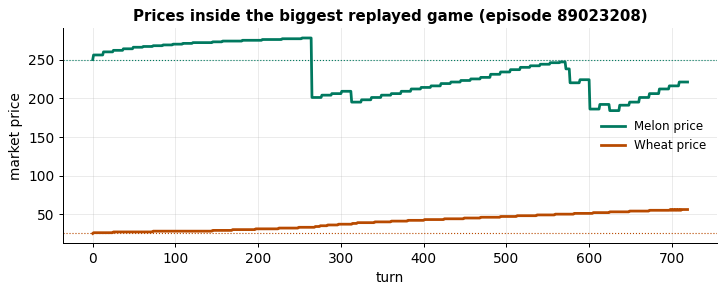

In this game melon starts at **250**, bottoms at **184** and peaks at **278**, a swing of 38% of its base price. Wheat runs **25–56** against a base of **25**. Wheat climbing that far above base usually means animal farms buying feed faster than the town supplies it. Both lines are a strategy log: you can see when a farm dumps and when it trickles.

In [7]:
rec_r = ladder_r.loc[ladder_r.winner_bank.idxmax()]
replay = load_replay(rec_r.episode_id)
prices = {p: [s[0]["observation"]["market"]["prices"][p] for s in replay["steps"]]
          for p in ("MELON", "WHEAT")}
base_price = {p: prices[p][0] for p in prices}

fig, ax = plt.subplots(figsize=(8.2, 3.4))
for p, c in (("MELON", C_TOP), ("WHEAT", C_MID)):
    ax.plot(prices[p], lw=2.2, color=c, label=f"{p.title()} price")
    ax.axhline(base_price[p], color=c, lw=.9, ls=":")
ax.set_xlabel("turn"); ax.set_ylabel("market price")
ax.set_title(f"Prices inside the biggest replayed game (episode {rec_r.episode_id})")
ax.legend(fontsize=9.5, frameon=False); plt.tight_layout(); plt.show()

mel, whe = prices["MELON"], prices["WHEAT"]
wheat_note = (" Wheat climbing that far above base usually means animal farms buying feed faster "
              "than the town supplies it." if max(whe) > base_price["WHEAT"] * 1.4 else "")
display(Markdown(
    f"In this game melon starts at **{base_price['MELON']}**, bottoms at **{min(mel)}** and peaks "
    f"at **{max(mel)}**, a swing of {(max(mel) - min(mel)) / base_price['MELON']:.0%} of its base "
    f"price. Wheat runs **{min(whe)}–{max(whe)}** against a base of **{base_price['WHEAT']}**."
    f"{wheat_note} Both lines are a strategy log: you can see when a farm dumps and when it "
    f"trickles."))

<a id="s6"></a>
## 6. How fast the bar is moving

The number every competitor wants: how much the ladder improves while you sleep. Median
winning bank per time slice, against the record so far. Skip a few days and this is the gap you
come back to.

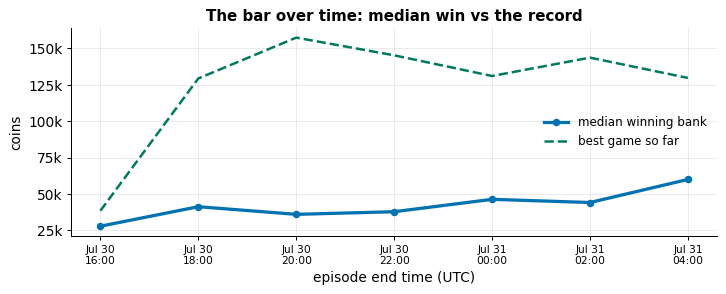

The median winning bank went from **27,880** to **60,016** over **12 hours** of ladder: **+115%**, and the most recent day moved **+29%** against the day before. A bot that stands still slides down the table on its own.

In [8]:
span_d6 = (ladder.end.max() - ladder.end.min()).total_seconds() / 86400
freq6 = "2h" if span_d6 <= 3 else ("6h" if span_d6 <= 10 else ("1D" if span_d6 <= 30 else "3D"))
by_h = (ladder.set_index("end").winner_bank
        .resample(freq6).agg(["median", "max", "count"]).dropna())
solid = by_h[by_h["count"] >= 2]
if len(solid) >= 4:
    by_h = solid
fig, ax = plt.subplots(figsize=(8.2, 3.4))
ax.plot(by_h.index, by_h["median"], lw=2.6, color=C_ACC,
        marker="o" if len(by_h) <= 48 else None, ms=5, label="median winning bank")
ax.plot(by_h.index, by_h["max"], lw=2, color=C_TOP, ls="--", label="best game so far")
ax.set_ylabel("coins"); ax.set_xlabel("episode end time (UTC)")
ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k" if v else "0")
ax.set_title("The bar over time: median win vs the record")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %d\n%H:%M"))
ax.tick_params(axis="x", labelsize=8.5)
ax.legend(fontsize=9.5, frameon=False)
plt.tight_layout(); plt.show()

first, last = by_h["median"].iloc[0], by_h["median"].iloc[-1]
hours = (by_h.index[-1] - by_h.index[0]).total_seconds() / 3600
daily = ladder.set_index("end").winner_bank.resample("1D").median().dropna()
move_txt = f": **{(last / first - 1) * 100:+.0f}%**" if first else ""
day_txt = (f", and the most recent day moved **{(daily.iloc[-1] / daily.iloc[-2] - 1) * 100:+.0f}%** "
           f"against the day before" if len(daily) >= 2 and daily.iloc[-2] > 0 else "")
tail_line = ("A bot that stands still slides down the table on its own." if last >= first else
             "The median can dip when new bots flood in; the record line is the bar that matters.")
display(Markdown(
    f"The median winning bank went from **{fmt(first)}** to **{fmt(last)}** over "
    f"**{hours:.0f} hours** of ladder{move_txt}{day_txt}. {tail_line}"))

<a id="s7"></a>
## 7. Who beats whom

Ratings compress everything into one number, and that hides the interesting part: matchups don't
have to be transitive. Head-to-head win rates between the busiest teams; read a row as the row
team's share of wins against the column team.

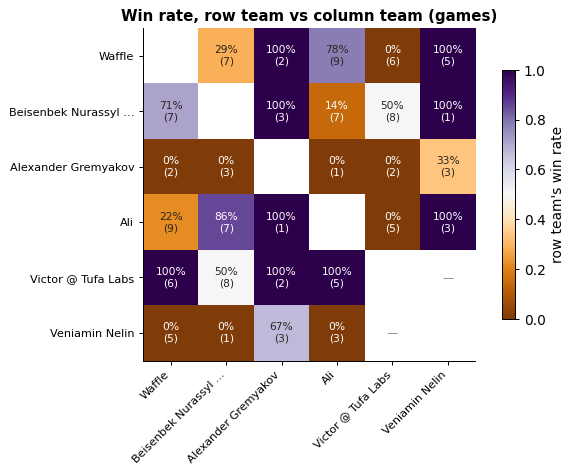

Cells are blank where the pair has not met yet; early ladders are sparse. Clean sweeps so far: **Waffle** over **Alexander Gremyakov** (2 games); **Waffle** over **Veniamin Nelin** (5 games); **Beisenbek Nurassyl [dsmlkz]** over **Alexander Gremyakov** (3 games).

In [9]:
lad = ladder.dropna(subset=["team_0", "team_1"]).copy()
lad["winner_team"] = np.where(lad.bank_0 >= lad.bank_1, lad.team_0, lad.team_1)
busiest = (pd.concat([lad.team_0, lad.team_1]).value_counts().head(6).index.tolist())
mat = pd.DataFrame(np.nan, index=busiest, columns=busiest, dtype=float)
counts = pd.DataFrame(0, index=busiest, columns=busiest, dtype=int)
for a in busiest:
    for b in busiest:
        if a == b:
            continue
        games = lad[((lad.team_0.eq(a) & lad.team_1.eq(b))
                     | (lad.team_0.eq(b) & lad.team_1.eq(a)))]
        if len(games):
            mat.loc[a, b] = games.winner_team.eq(a).mean()
            counts.loc[a, b] = len(games)

labels = [(n if len(n) <= 20 else n[:19] + "…")
          for n in (name_of(t) for t in busiest)]
fig, ax = plt.subplots(figsize=(7.4, 5.4))
im = ax.imshow(mat.values, cmap="PuOr", vmin=0, vmax=1)
ax.set_xticks(range(len(busiest)), labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(busiest)), labels, fontsize=9)
for i in range(len(busiest)):
    for j in range(len(busiest)):
        v, n = mat.values[i, j], counts.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\n({n})", ha="center", va="center", fontsize=8.5,
                    color="white" if abs(v - .5) > .3 else "#2B241D")
        elif i != j:
            ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="#8A8073")
ax.set_title("Win rate, row team vs column team (games)")
ax.grid(False); fig.colorbar(im, ax=ax, shrink=.75, label="row team's win rate")
plt.tight_layout(); plt.show()

upsets = [(r, c, mat.loc[r, c]) for r in busiest for c in busiest
          if not np.isnan(mat.loc[r, c]) and mat.loc[r, c] >= .999 and counts.loc[r, c] >= 2]
n_blank = int(np.isnan(mat.values).sum()) - len(busiest)
intro_hh = ("Every pair here has met at least once. " if n_blank == 0 else
            "Cells are blank where the pair has not met yet; early ladders are sparse. ")
display(Markdown(
    intro_hh
    + (f"Clean sweeps so far: "
       + "; ".join(f"**{name_of(r)}** over **{name_of(c)}** ({counts.loc[r, c]} games)"
                   for r, c, _ in upsets[:3]) + "."
       if upsets else "No clean sweeps yet among the busiest teams.")))

<a id="s8"></a>
## 8. How much of this is luck

Same bot, different games: how wide is its spread? This decides how many submissions you need
before believing a result, and whether that one great game was skill or a lucky matchup.

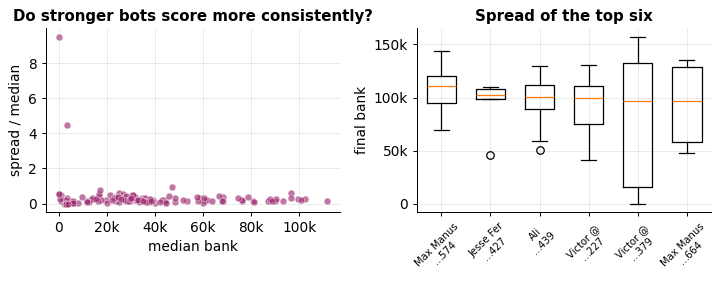

Across submissions with at least four games, the typical spread is **19%** of the median bank (worst: **950%**). One episode proves little, which is why the ladder keeps playing more of them.

In [10]:
per_sub = (agents[agents.episode_id.isin(ladder.episode_id)]
           .groupby("submission_id").final_bank
           .agg(["count", "median", "std"]).query("count >= 4 and median > 0").dropna())
per_sub["cv"] = per_sub["std"] / per_sub["median"]
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.3))
axes[0].scatter(per_sub["median"], per_sub["cv"], s=30, alpha=.65, color=C_LOW,
                edgecolors="white", lw=.5)
axes[0].set_xlabel("median bank"); axes[0].set_ylabel("spread / median")
axes[0].xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k" if v else "0")
axes[0].set_title("Do stronger bots score more consistently?")
top_ids = per_sub["median"].nlargest(6).index
lad_agents = agents[agents.episode_id.isin(ladder.episode_id)]
box = [lad_agents[lad_agents.submission_id.eq(s)].final_bank.values for s in top_ids]
axes[1].boxplot(box, widths=.6)
axes[1].set_xticks(range(1, len(top_ids) + 1),
                   [name_of(lad_agents[lad_agents.submission_id.eq(s)].team_id.iloc[0])[:9]
                    + f"\n…{str(s)[-3:]}" for s in top_ids])
axes[1].set_title("Spread of the top six"); axes[1].set_ylabel("final bank")
axes[1].yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k" if v else "0")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout(); plt.show()

display(Markdown(
    f"Across submissions with at least four games, the typical spread is "
    f"**{per_sub.cv.median():.0%}** of the median bank (worst: **{per_sub.cv.max():.0%}**). "
    f"One episode proves little, which is why the ladder keeps playing more of them."))

<a id="s9"></a>
## 9. Your submission against the ladder

The part worth forking. Put your own submission id in the cell below and you get a personal
report: where your best game lands in the whole field, and how your strategy fingerprint
compares with the record holder's. Find your id in `episodes.csv`, or leave the default to see
the record holder's own report.

In [11]:
SUBMISSION_ID = int(top_subs.index[0])   # TWEAK THIS: your submission id from episodes.csv

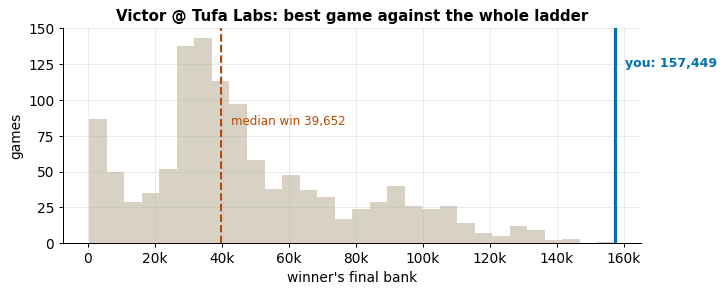

,best bank,games,hires / day,peak crew,first land (day),top crop
Victor @ Tufa Labs,"157,449",34,10.8,13,0,Strawberry
Victor @ Tufa Labs (record holder),"157,449",34,10.8,13,0,Strawberry


**Victor @ Tufa Labs** has **34** ladder games on record; its best bank of **157,449** beats **100%** of all recorded wins. The row below it is the record holder; the gap in crew size and land timing is usually where the difference starts.

In [12]:
mine = ladder_r[ladder_r.sub_0.eq(SUBMISSION_ID) | ladder_r.sub_1.eq(SUBMISSION_ID)].copy()
mine["my_seat"] = mine.sub_1.eq(SUBMISSION_ID).astype(int)
mine["my_bank"] = np.where(mine.my_seat.eq(1), mine.bank_1, mine.bank_0)
if mine.empty or mine.my_bank.isna().all():
    display(Markdown(
        f"No replayed ladder games for submission **{SUBMISSION_ID}** yet — the crawler usually "
        f"catches up within a day. Check the id in `episodes.csv` or try tomorrow."))
else:
    best = mine.loc[mine.my_bank.idxmax()]
    my_team = name_of(best.team_1 if best.my_seat else best.team_0)
    pct = (ladder.winner_bank < best.my_bank).mean()

    fig, ax = plt.subplots(figsize=(8.2, 3.4))
    ax.hist(ladder.winner_bank, bins=30, color="#D8D2C4")
    ax.axvline(best.my_bank, color=C_ACC, lw=2.6)
    ax.axvline(ladder.winner_bank.median(), color=C_MID, lw=1.6, ls="--")
    ax.annotate(f"you: {fmt(best.my_bank)}", xy=(best.my_bank, ax.get_ylim()[1] * .82),
                xytext=(8, 0), textcoords="offset points", color=C_ACC, weight="bold", fontsize=10)
    ax.annotate(f"median win {fmt(ladder.winner_bank.median())}",
                xy=(ladder.winner_bank.median(), ax.get_ylim()[1] * .55),
                xytext=(8, 0), textcoords="offset points", color=C_MID, fontsize=9.5)
    ax.set_xlabel("winner's final bank"); ax.set_ylabel("games")
    ax.xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k" if v else "0")
    ax.set_title(f"{my_team}: best game against the whole ladder")
    plt.tight_layout(); plt.show()

    rid = int(top_subs.index[0])
    my_fp = fingerprint(best.episode_id, int(best.my_seat))
    lead_fp = rows[0]
    top_crop_of = lambda f: (max(f["plants"], key=f["plants"].get).title()
                             if f["plants"] else "—")
    compare = pd.DataFrame([
        {"": my_team, "best bank": best.my_bank, "games": len(mine),
         "hires / day": my_fp["hires / day"], "peak crew": my_fp["peak crew"],
         "first land (day)": my_fp["first land (day)"], "top crop": top_crop_of(my_fp)},
        {"": f"{lead_fp['who']} (record holder)", "best bank": lead_fp["bank"],
         "games": int((ladder_r.sub_0.eq(rid) | ladder_r.sub_1.eq(rid)).sum()),
         "hires / day": lead_fp["hires / day"], "peak crew": lead_fp["peak crew"],
         "first land (day)": lead_fp["first land (day)"], "top crop": top_crop_of(lead_fp)},
    ])
    display(compare.style.hide(axis="index")
            .format({"best bank": "{:,.0f}", "hires / day": "{:.1f}",
                     "first land (day)": "{:.0f}"}, na_rep="—")
            .set_properties(**{"font-size": "13px"})
            .set_table_styles([{"selector": "th", "props": [("font-size", "13px")]}]))

    display(Markdown(
        f"**{my_team}** has **{len(mine)}** ladder games on record; its best bank of "
        f"**{fmt(best.my_bank)}** beats **{pct:.0%}** of all recorded wins. "
        f"The row below it is the record holder; the gap in crew size and land timing is "
        f"usually where the difference starts."))

<a id="s10"></a>
## Before you quote these numbers

The honest edges of this snapshot, so the charts above don't overclaim:

- Fingerprints read one best game per submission: a sketch of a strategy at its peak, not its
  average behavior.
- The corpus is a crawl, not a census. Episodes are discovered through pairings, so a brand-new
  submission can lag behind the ladder by a few hours; section 1 prints the exact replay
  coverage.
- Head-to-head cells stand on a handful of games. The count is printed inside every cell; a 100%
  built on two games is an anecdote, not a verdict.
- Spread estimates use submissions with four or more games each, a modest per-bot sample even
  on a mature ladder; treat them as order-of-magnitude.
- Validation (self-play) episodes are excluded from every strength comparison; section 1 shows
  their share of the raw data.

In [13]:
lead_row = fp.iloc[0]
elbow_txt = ("" if not elbows else
             (f"day **{min(elbows.values())}**"
              if min(elbows.values()) == max(elbows.values())
              else f"day **{min(elbows.values())}–{max(elbows.values())}**"))
land_txt = ("no land purchase at all" if pd.isna(lead_row["first land (day)"])
            else f"land on day **{lead_row['first land (day)']:.0f}**")
crop_txt = (f"and the biggest wins all lead with {uniq_crops[0]}" if len(uniq_crops) == 1
            else "while the biggest wins disagree on which crop to lead with")
display(Markdown(textwrap.dedent(f'''
<a id="s11"></a>
## Takeaways ({AS_OF:%b %d, %Y} snapshot)

1. The ladder's spread is wide: the record win of **{fmt(rec.winner_bank)}** is
   **{rec.winner_bank / q[.5]:.1f}×** the median win of **{fmt(q[.5])}**.
2. Big games share one silhouette: reinvest almost everything, then compound. The leaders cross
   a tenth of their final bank around in-game {elbow_txt}.
3. The record holder's measurable edge is labor and land: a crew of
   **{lead_row['peak crew']:.0f}** and {land_txt}, {crop_txt}.
4. Market prices inside a game are their own strategy log: in the biggest replayed game melon swung
   **{(max(prices["MELON"]) - min(prices["MELON"])) / base_price["MELON"]:.0%}** of its base price
   and wheat ran **{min(prices["WHEAT"])}–{max(prices["WHEAT"])}**.

The [dataset]({"https://www.kaggle.com/datasets/georgymamarin/kaggriculture-episodes"}) and this
notebook both refresh daily, so these numbers re-compute themselves as the meta moves. Build
something on top (a deeper dive, an imitation model, a better fingerprint) and post it; I
feature community work on the dataset page. If there is a metric you want tracked here, say so
in the comments. Replays come from Kaggle's public episode service; credit to the hosts for
keeping it open. For the rules behind these curves, see
[Kaggriculture, Visualized](https://www.kaggle.com/code/georgymamarin/kaggriculture-visualized-what-every-crop-pays).

*— [Georgy Mamarin](https://www.kaggle.com/georgymamarin)*
''')))


<a id="s11"></a>
## Takeaways (Jul 31, 2026 snapshot)

1. The ladder's spread is wide: the record win of **157,449** is
   **4.0×** the median win of **39,652**.
2. Big games share one silhouette: reinvest almost everything, then compound. The leaders cross
   a tenth of their final bank around in-game day **11–15**.
3. The record holder's measurable edge is labor and land: a crew of
   **13** and land on day **0**, while the biggest wins disagree on which crop to lead with.
4. Market prices inside a game are their own strategy log: in the biggest replayed game melon swung
   **38%** of its base price
   and wheat ran **25–56**.

The [dataset](https://www.kaggle.com/datasets/georgymamarin/kaggriculture-episodes) and this
notebook both refresh daily, so these numbers re-compute themselves as the meta moves. Build
something on top (a deeper dive, an imitation model, a better fingerprint) and post it; I
feature community work on the dataset page. If there is a metric you want tracked here, say so
in the comments. Replays come from Kaggle's public episode service; credit to the hosts for
keeping it open. For the rules behind these curves, see
[Kaggriculture, Visualized](https://www.kaggle.com/code/georgymamarin/kaggriculture-visualized-what-every-crop-pays).

*— [Georgy Mamarin](https://www.kaggle.com/georgymamarin)*
